# Plot maps of biases

In [1]:
import os
import xarray as xr
import pandas as pd
import geopandas as gpd
# import plotnine as p9
import mizani
from plotnine import (
    ggplot, aes, 
    geom_point, geom_raster, geom_tile,
    facet_wrap, facet_grid,
    coord_equal,
    xlim, ylim, ggtitle,
    scale_fill_distiller, scale_fill_gradient2,
    theme_bw, theme, element_blank, element_text
)
import regionmask

ERROR 1: PROJ: proj_create_from_database: Open of /mnt/CORDEX_CMIP6_tmp/user_tmp/mmatiu/conda_envs/jsc/share/proj failed


## settings and data-prep

In [2]:
ref_data = "cerra"
variable = "pr"
path_fig = os.path.abspath(os.path.join(os.getcwd(), "..", "fig/maps-singlemod-"+ref_data))
os.makedirs(path_fig, exist_ok=True)

In [3]:
gpd_regions = gpd.read_file("../data/regions.gpkg")
regions = regionmask.Regions.from_geodataframe(gpd_regions)

In [4]:
xds = xr.open_dataset("../intermediate-results/" + ref_data + "_" + variable + "_CMIP6_1991-2020_spatial_bias.nc")

In [5]:
mask = regions.mask_3D(xds["lon"], xds["lat"], drop=False)
df_mask = mask.to_dataframe().reset_index()
df_mask_tosubset = df_mask[["region", "rlat", "rlon", "names", "mask"]][df_mask["mask"]]

In [6]:
df = xds.to_dataframe().reset_index()
df_regions = pd.merge(df, df_mask_tosubset).dropna()

## test single

In [7]:
# df1 = df_regions[(df_regions["dset_id"]=="CNRM-ALADIN64E1") & 
#     (df_regions["season"] == "DJF")]

In [8]:
# (
#     ggplot(df1[df1["region"]==0], aes("rlon","rlat",fill="tas"))
#     + geom_raster()
#     # + scale_fill_distiller(type="div", limits=[-5,5], direction=-1)
#     + scale_fill_gradient2(mid="#f5f5f5", high="#d73027", low="#4575b4")
#     # + scale_fill_gradient2()
#     + facet_wrap("season")
#     + theme_bw()
#     + ggtitle(regions[0].name)
# )

In [9]:
# gg = (
#     ggplot(df_tas_regions[(df_regions["region"]==0) & 
#                           (df_regions["season"]=="DJF")], 
#            aes("rlon","rlat",fill=variable))
#     + geom_raster()
#     + scale_fill_gradient2(name = variable + "\n bias \n E-OBS", 
#                            mid="#f5f5f5", high="#d73027", low="#4575b4")
#     # + facet_grid("season", "dset_id")
#     + facet_wrap("dset_id")
#     + coord_equal()
#     + theme_bw()
#     + theme(axis_title=element_blank(), 
#             axis_ticks=element_blank(), 
#             axis_text=element_blank())
#     + ggtitle(regions[0].name)
# )
# gg.show()
# # gg.save("test.png", width=12, height=8, dpi=300)

## Plots

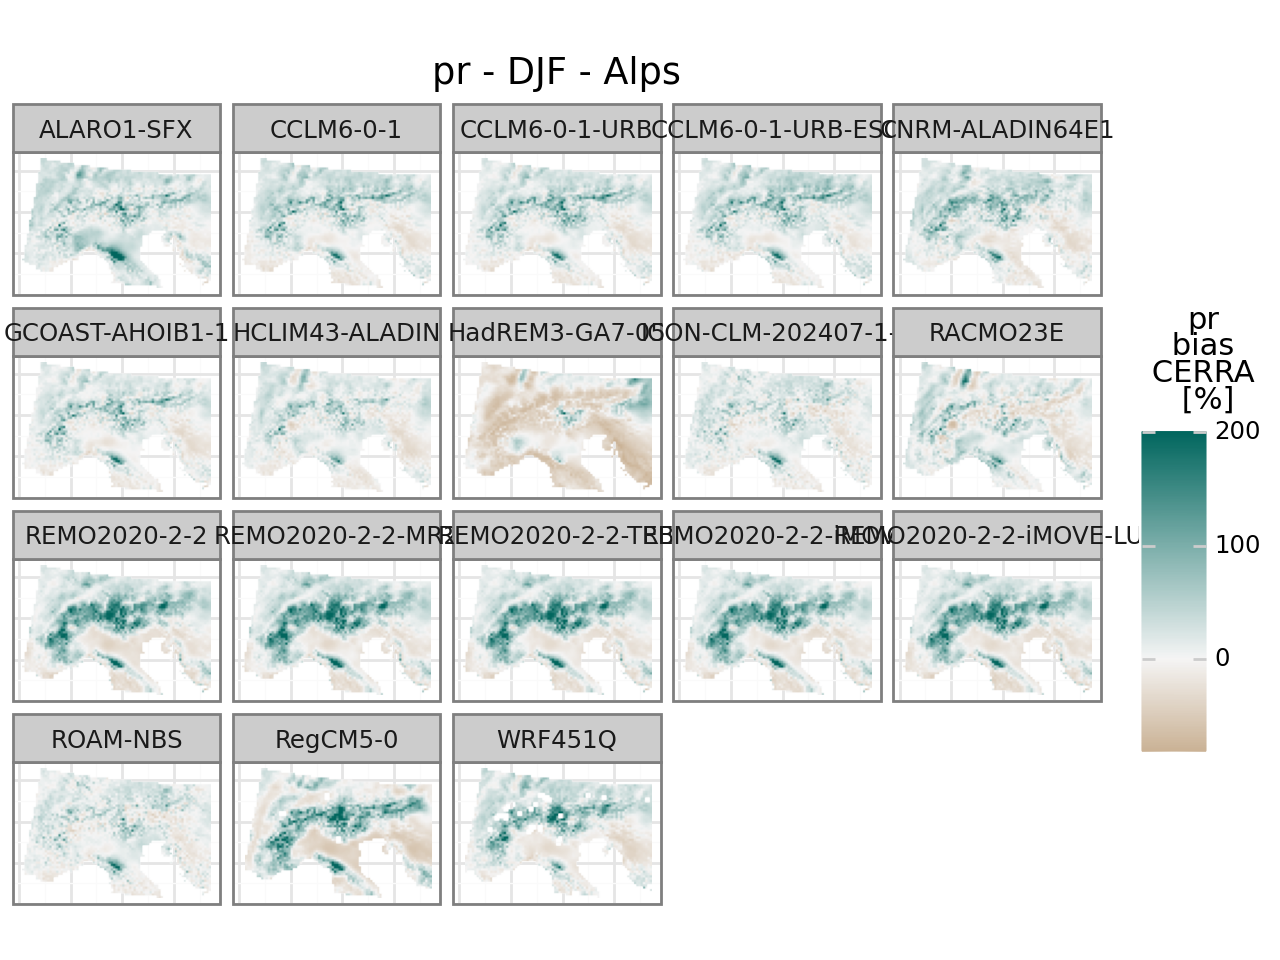

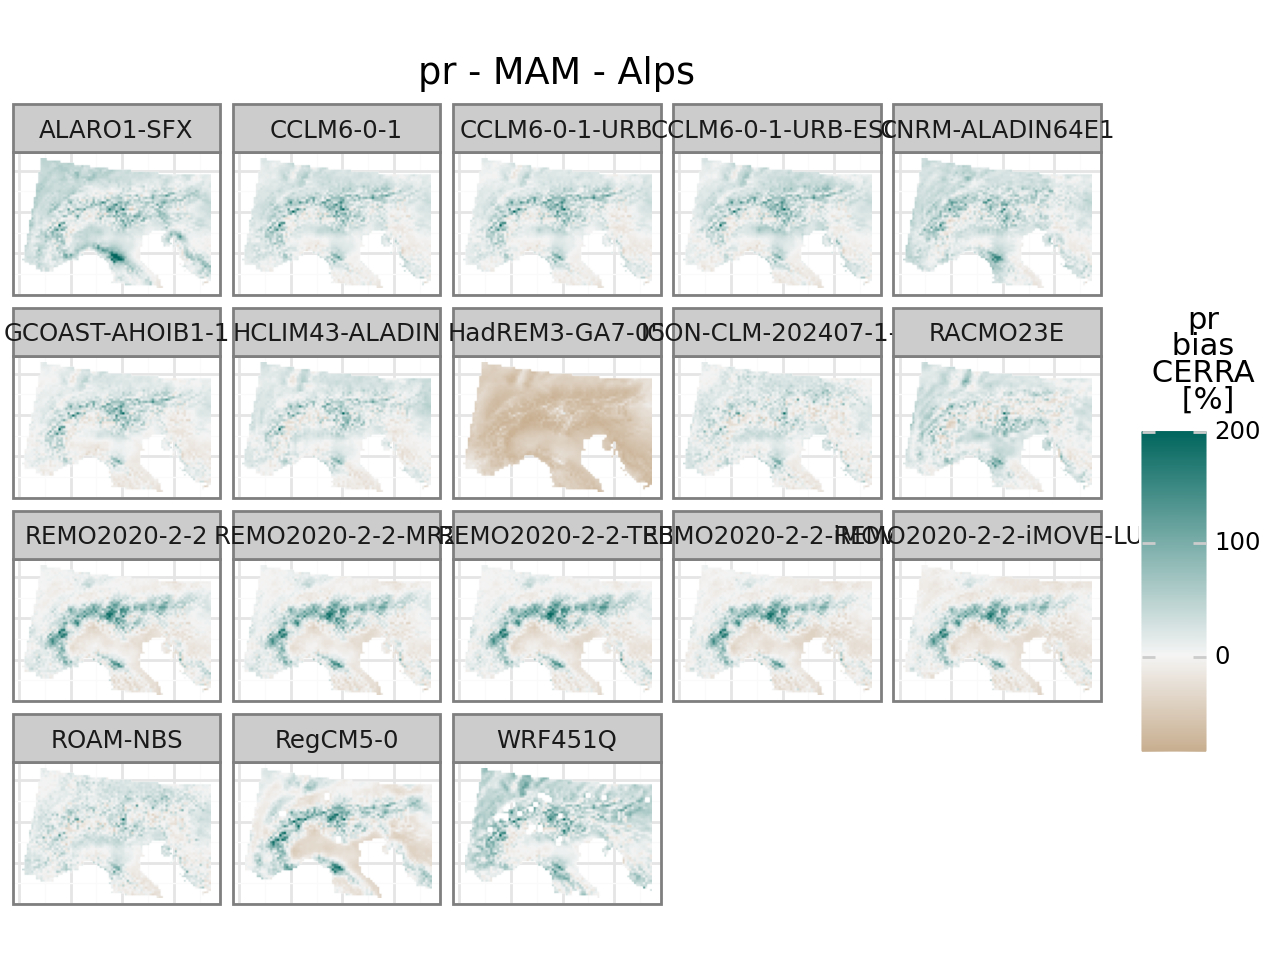

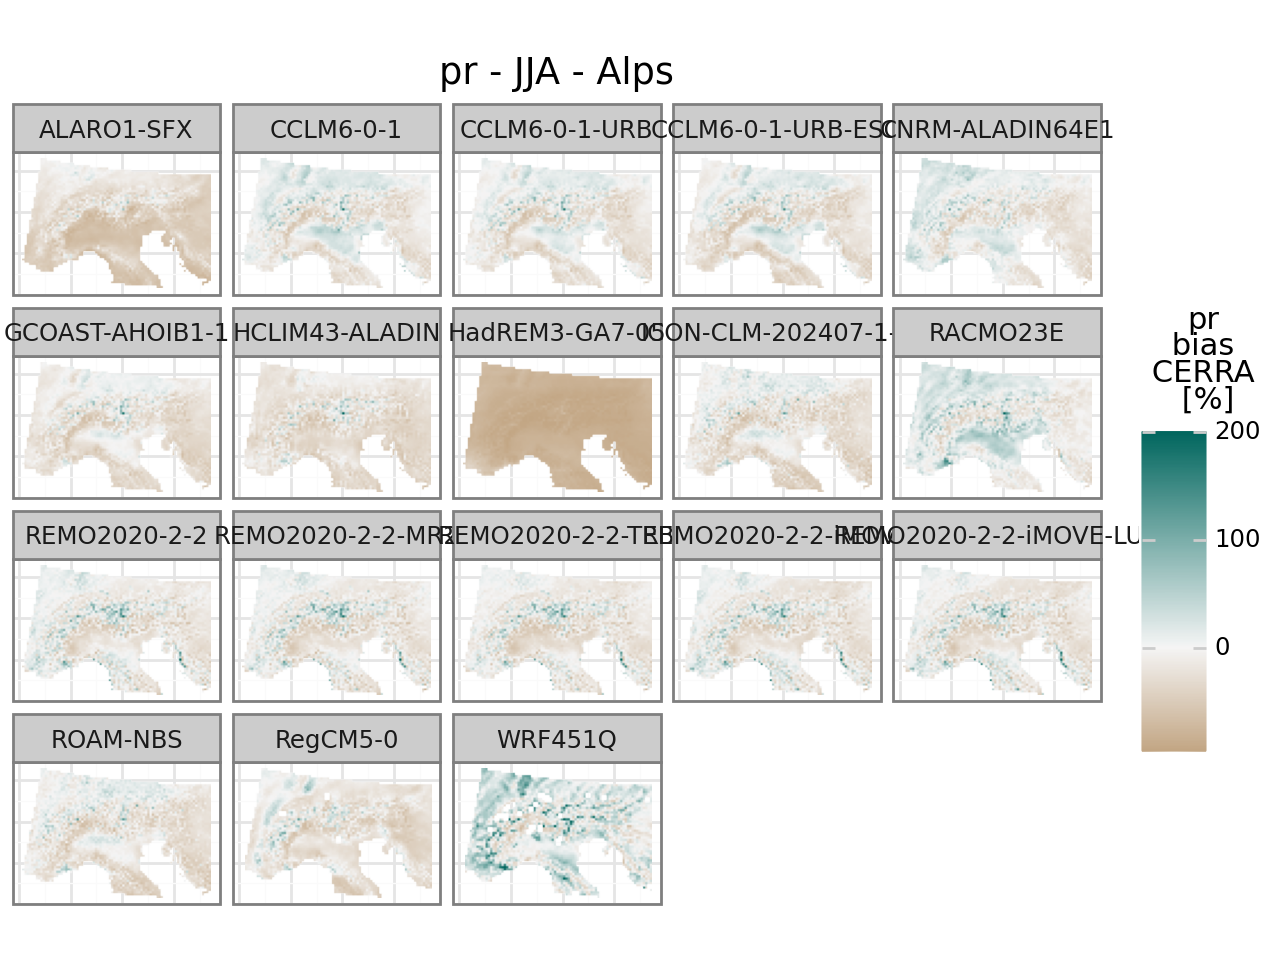

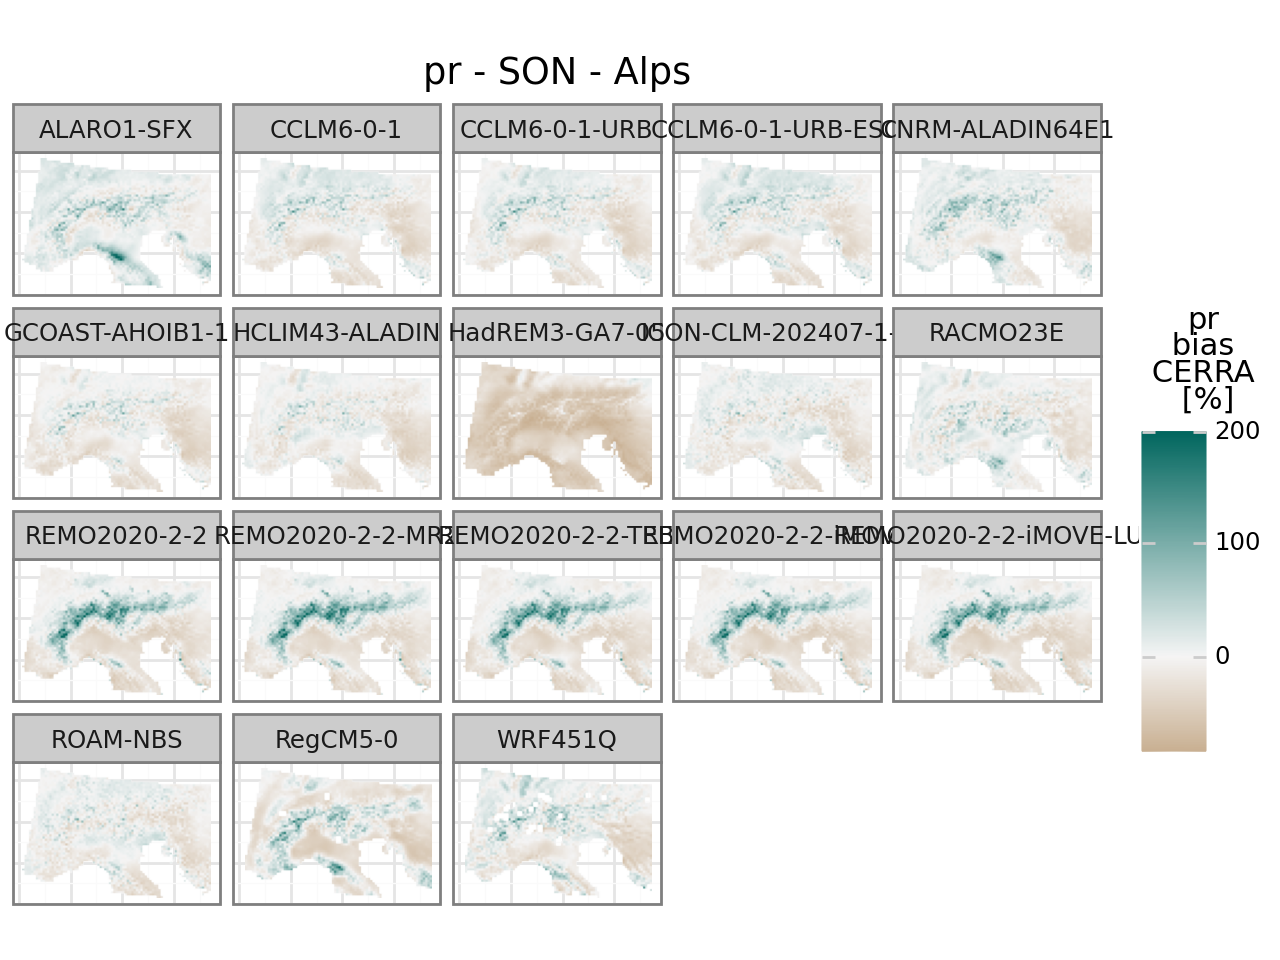

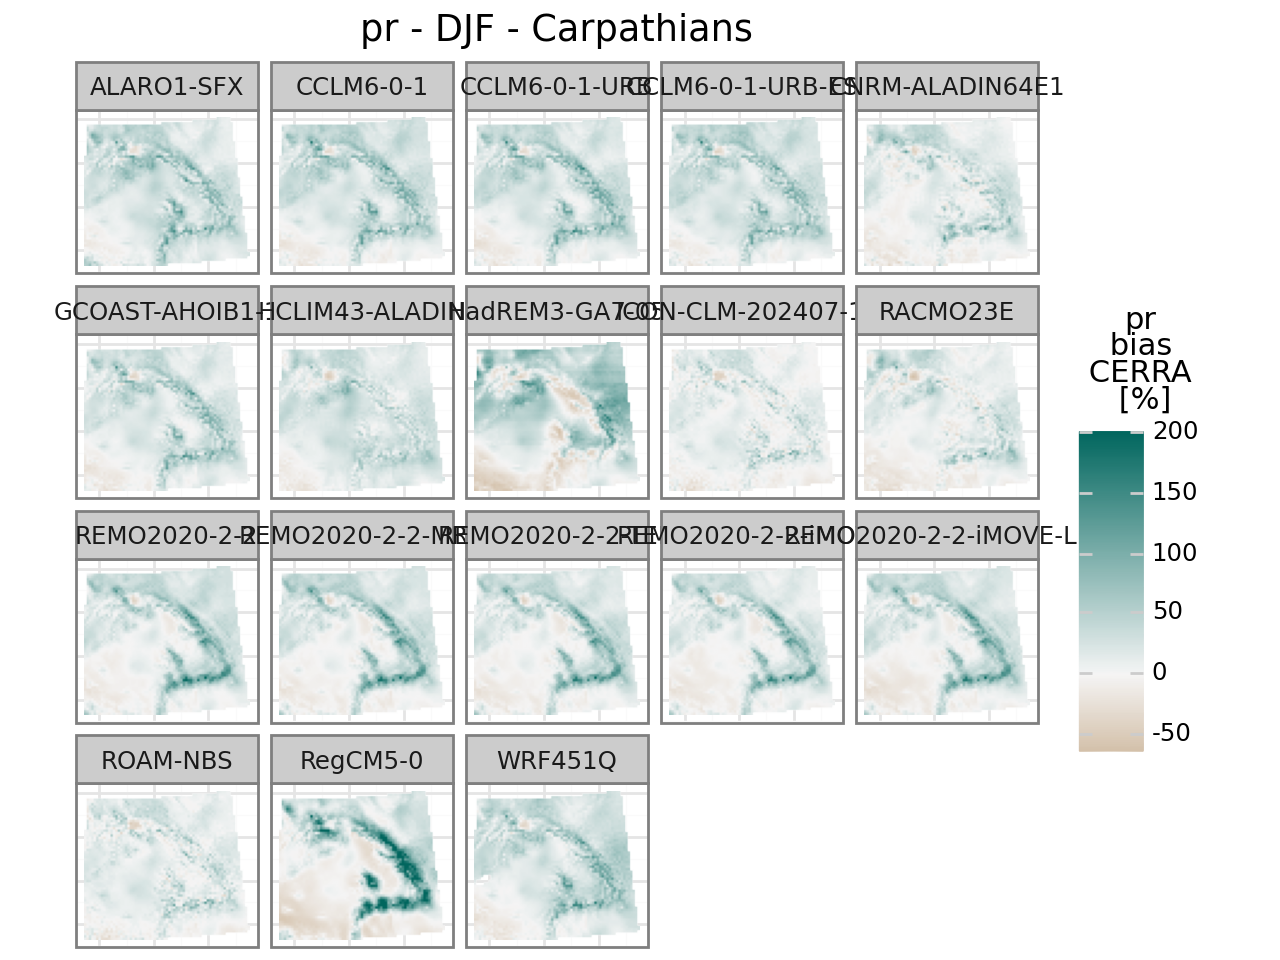

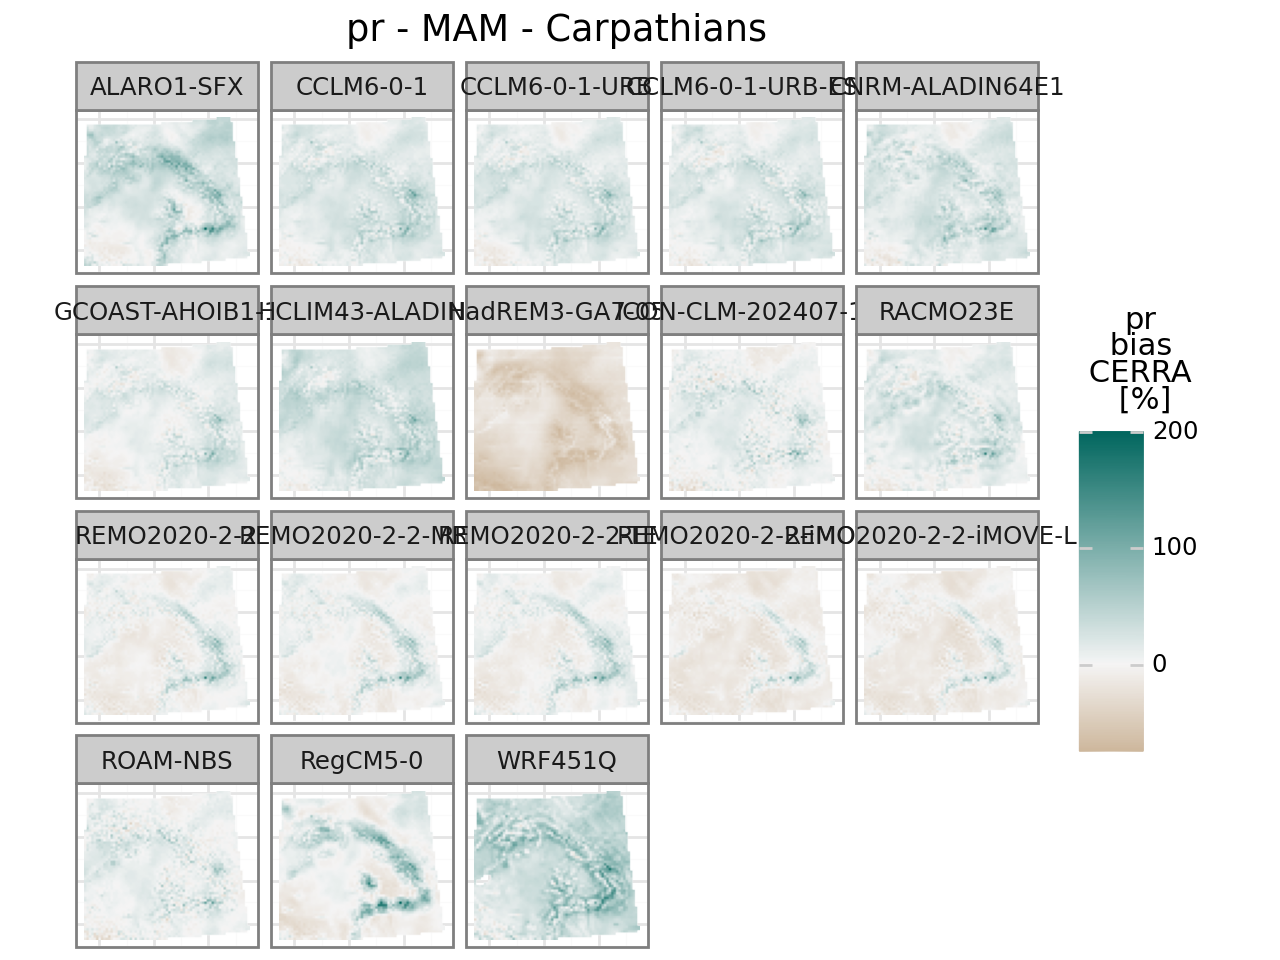

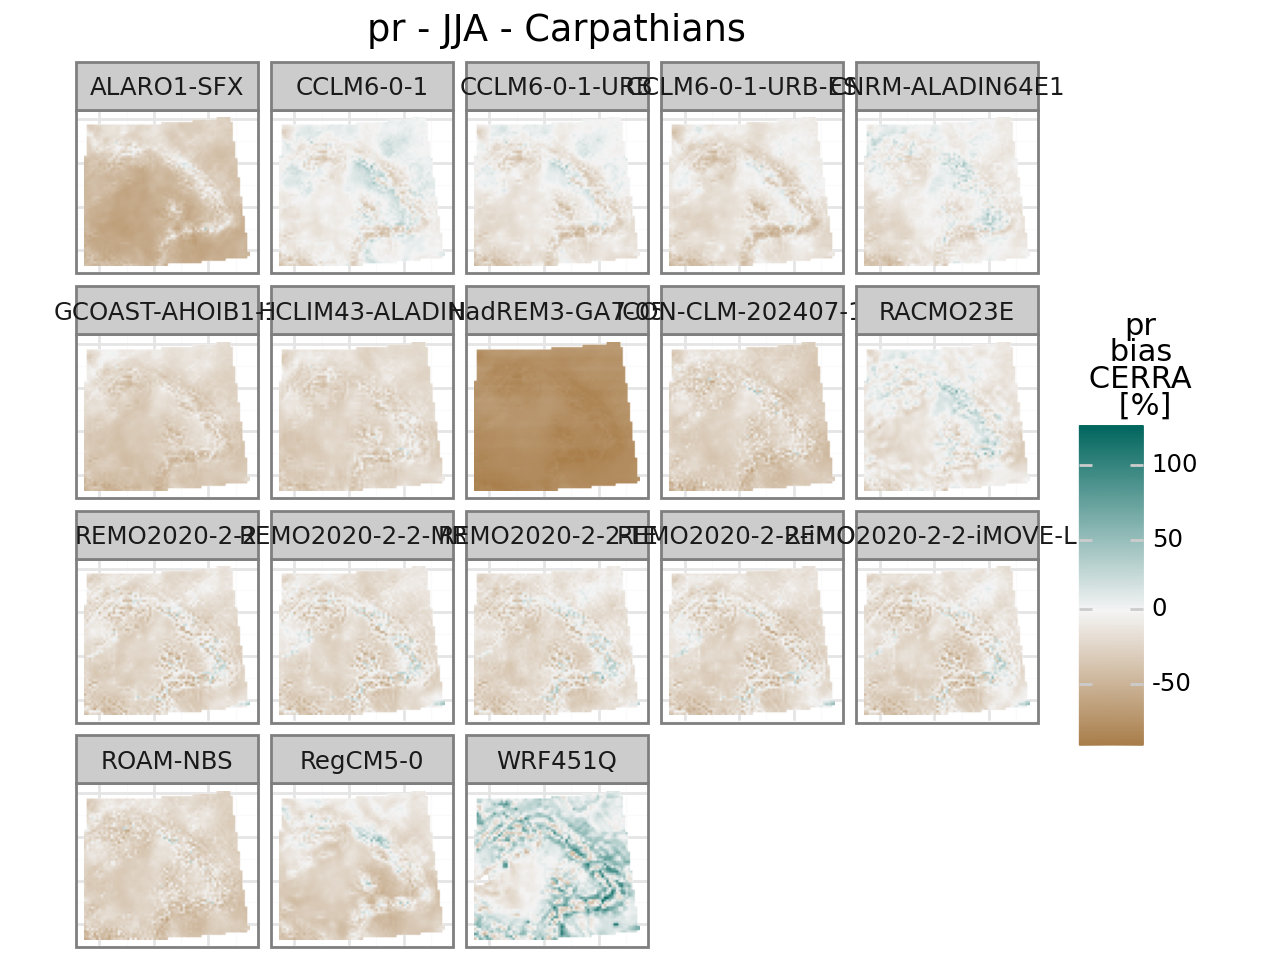

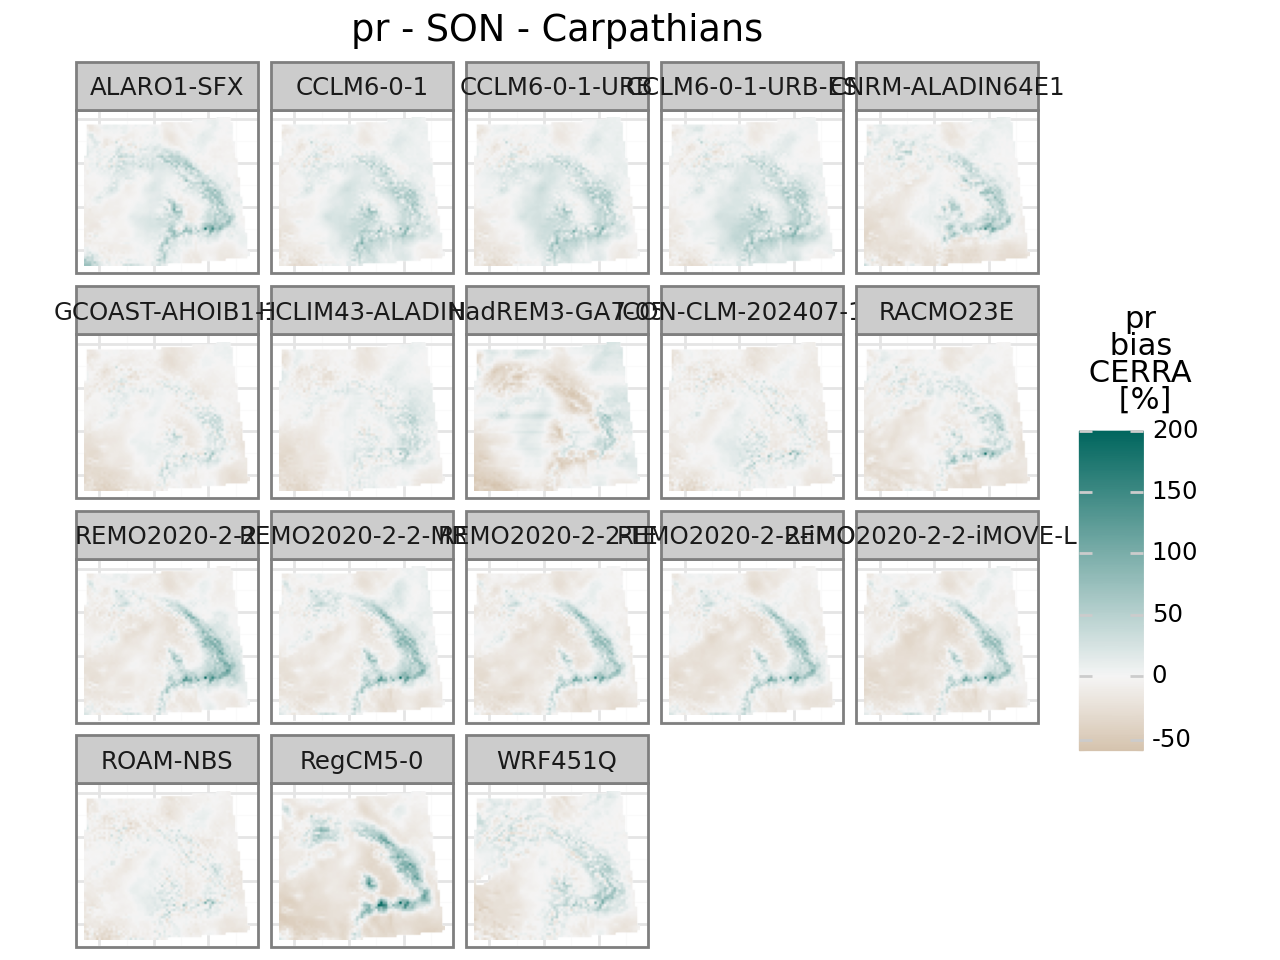

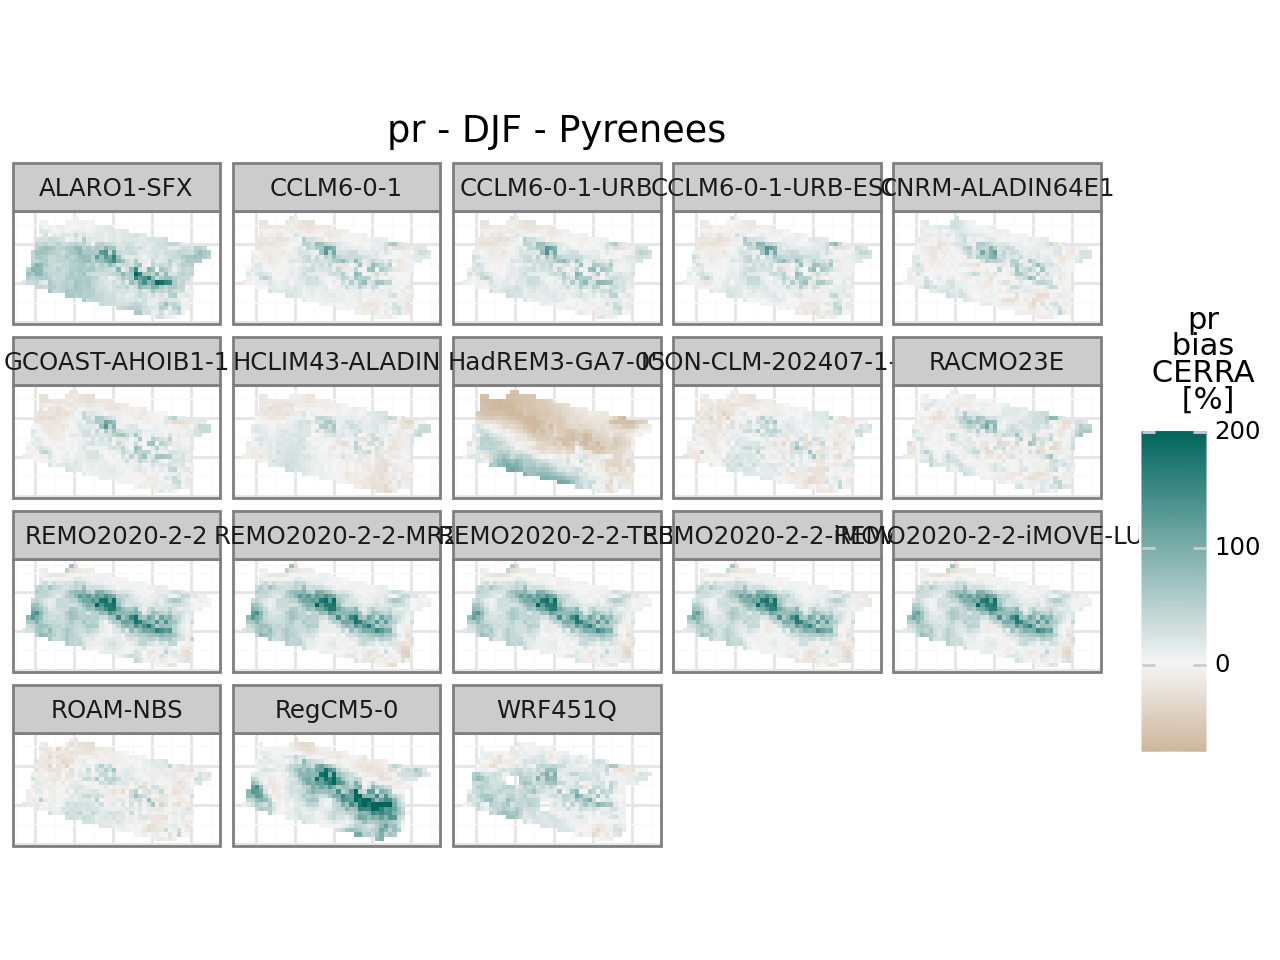

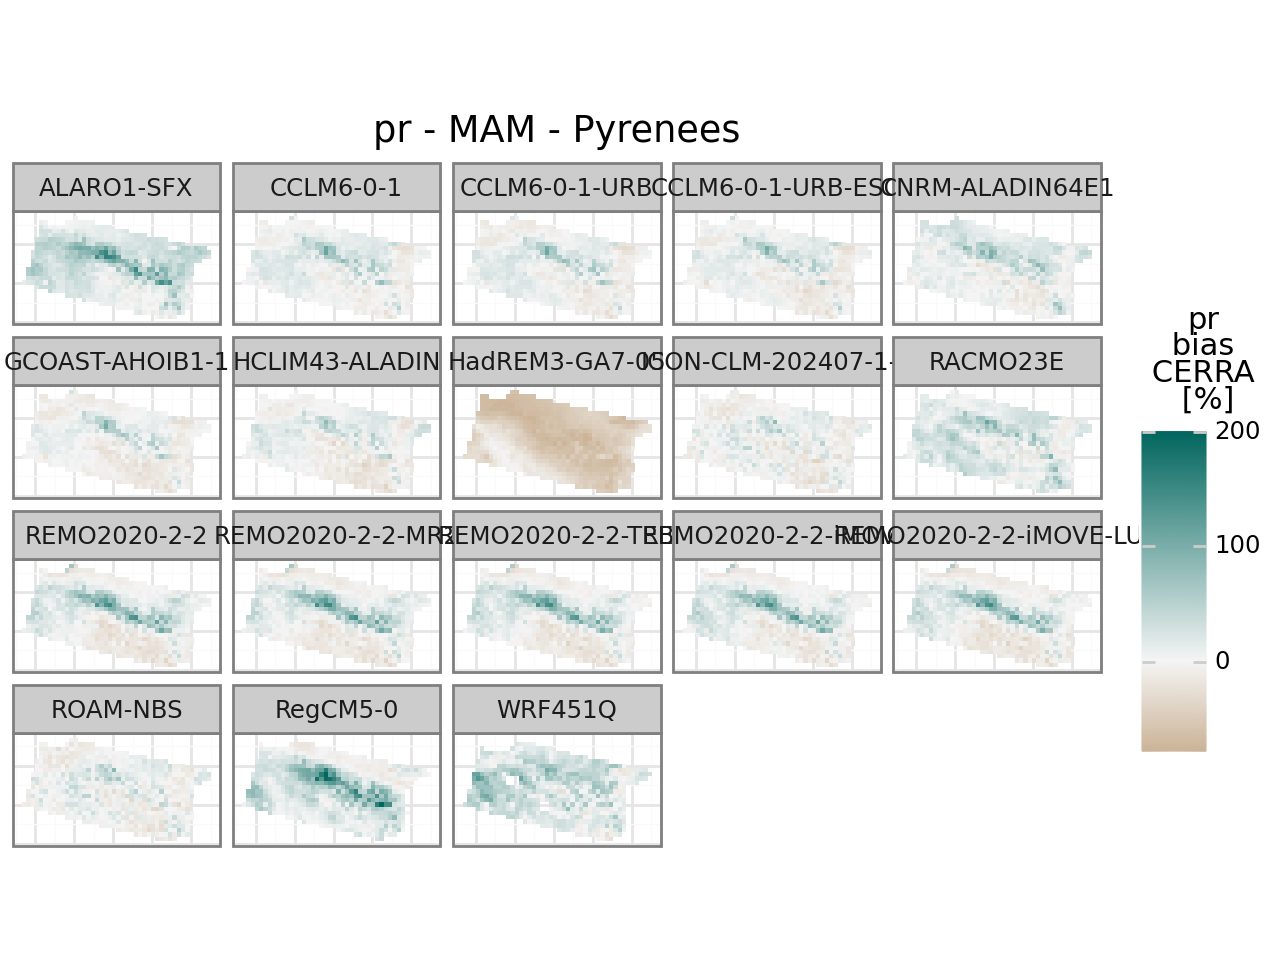

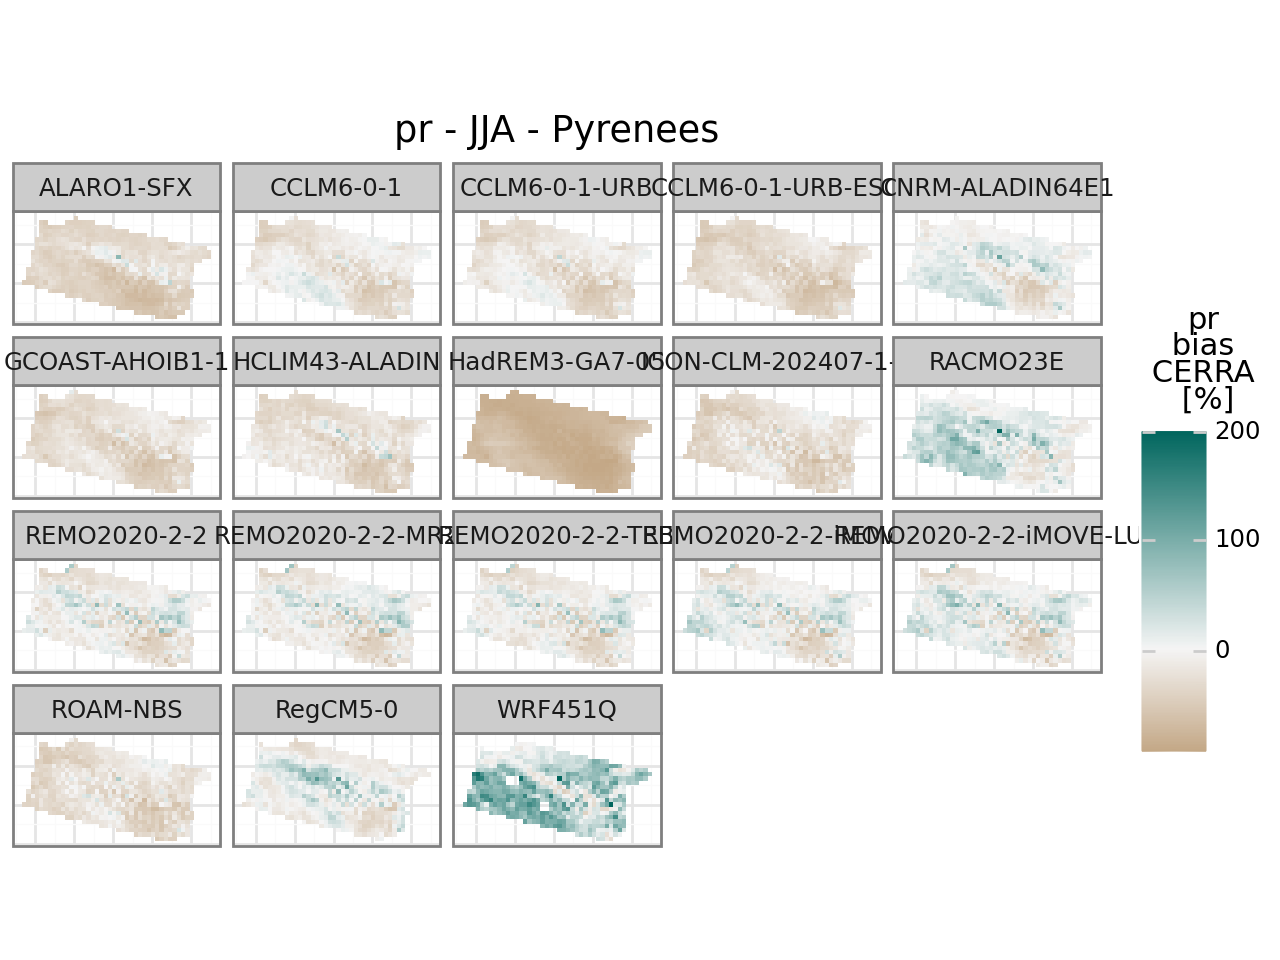

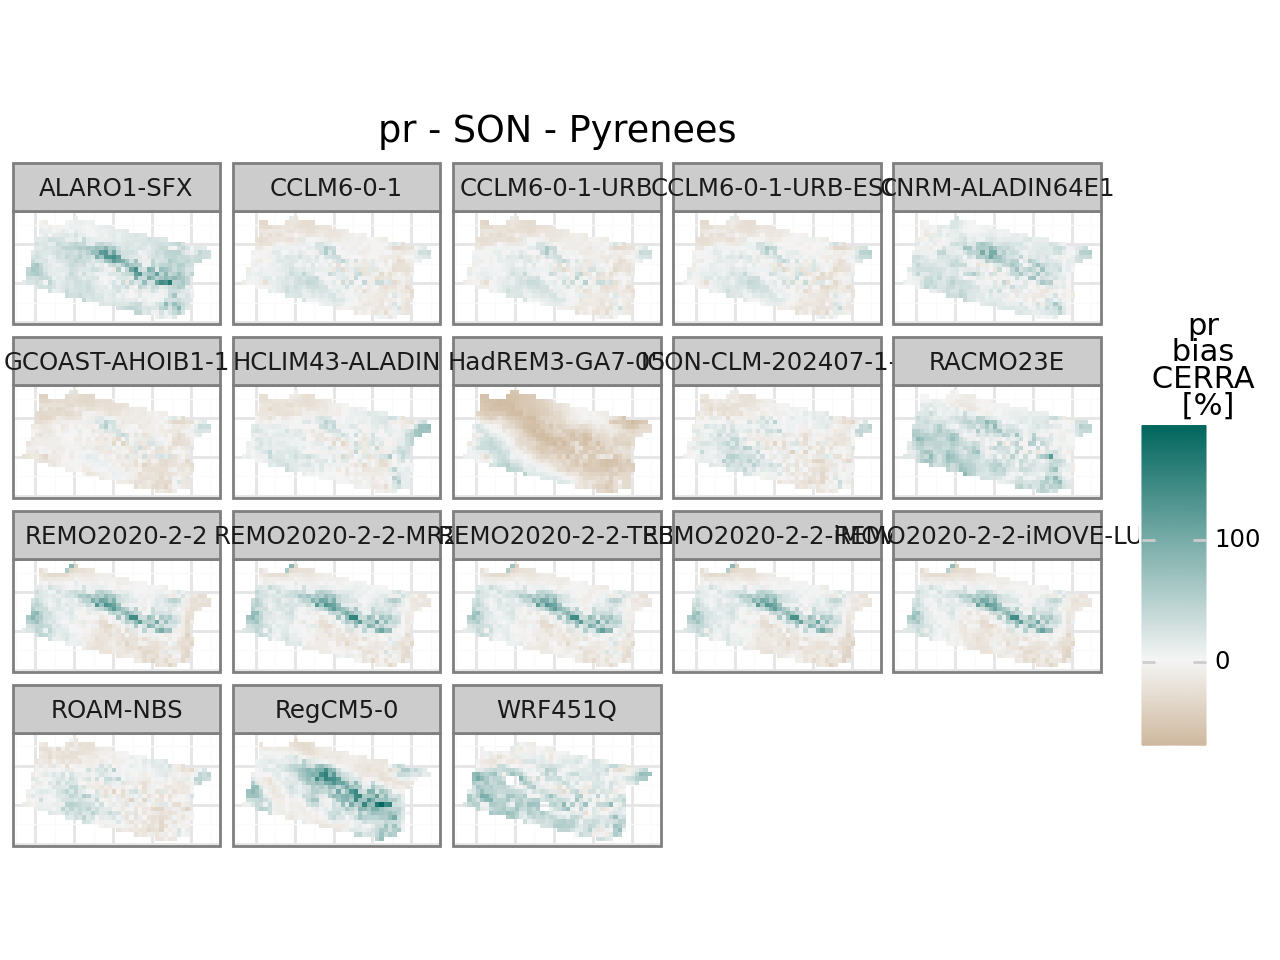

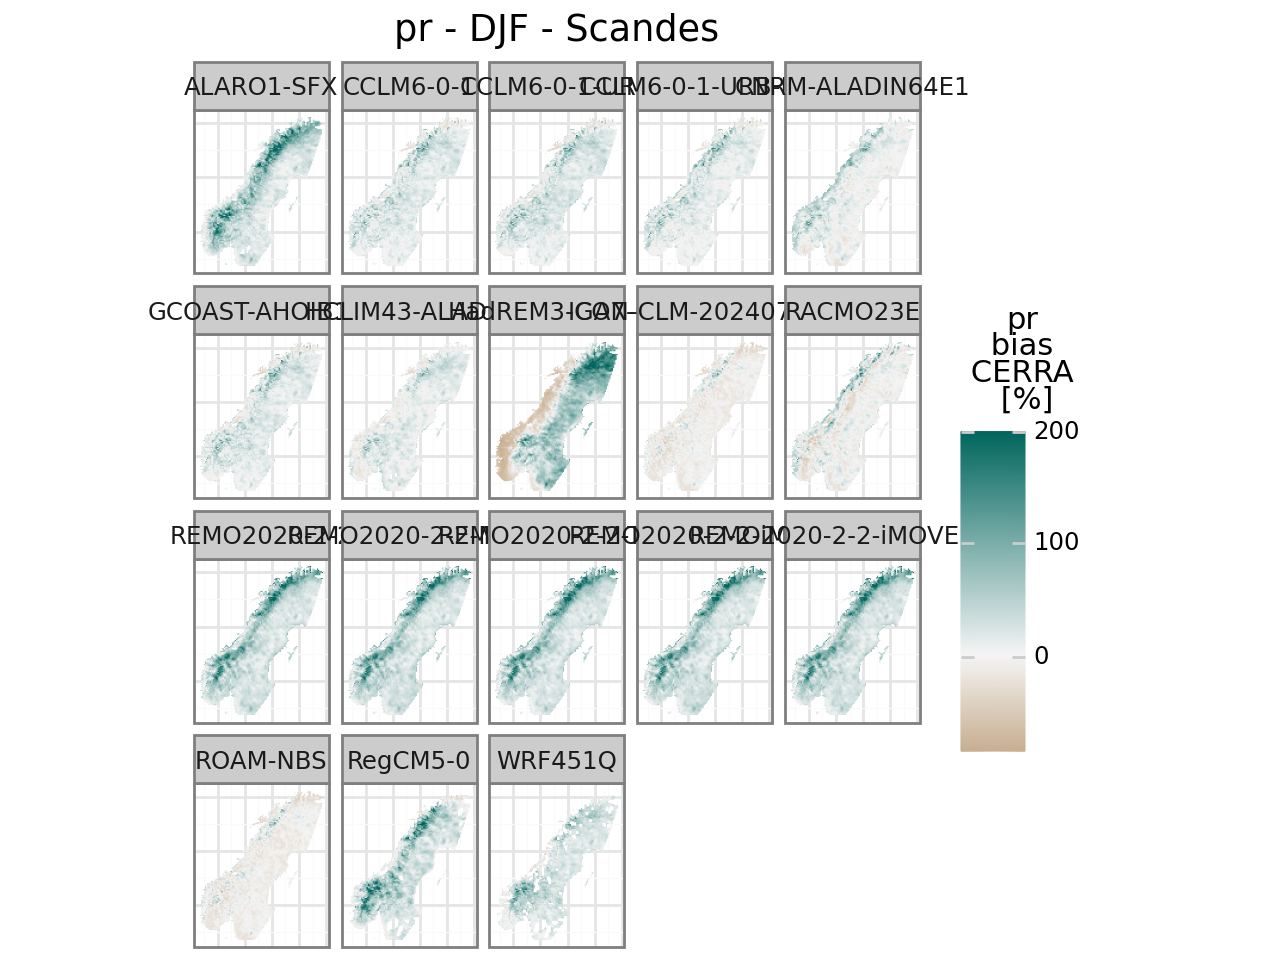

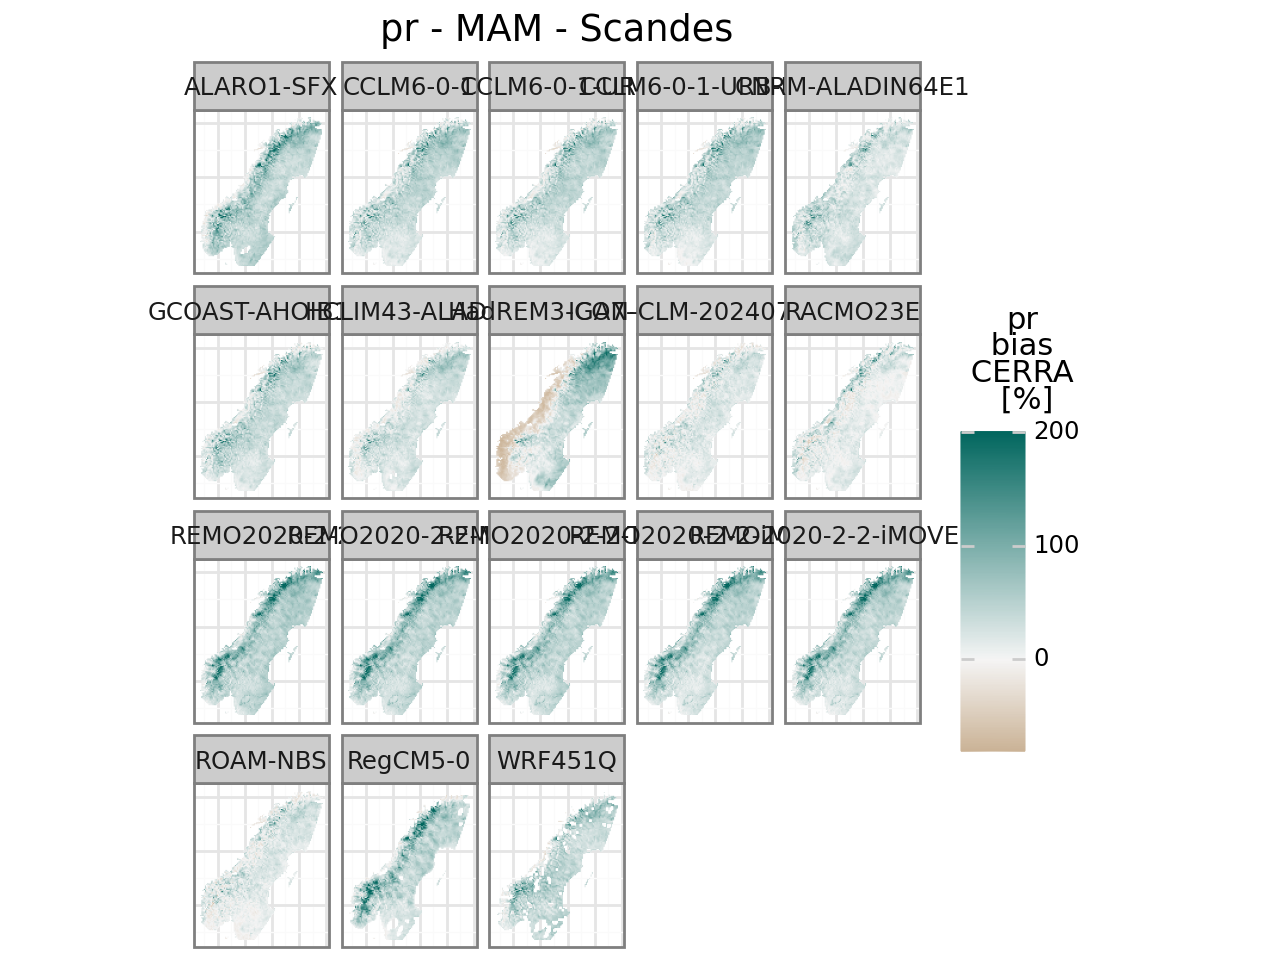

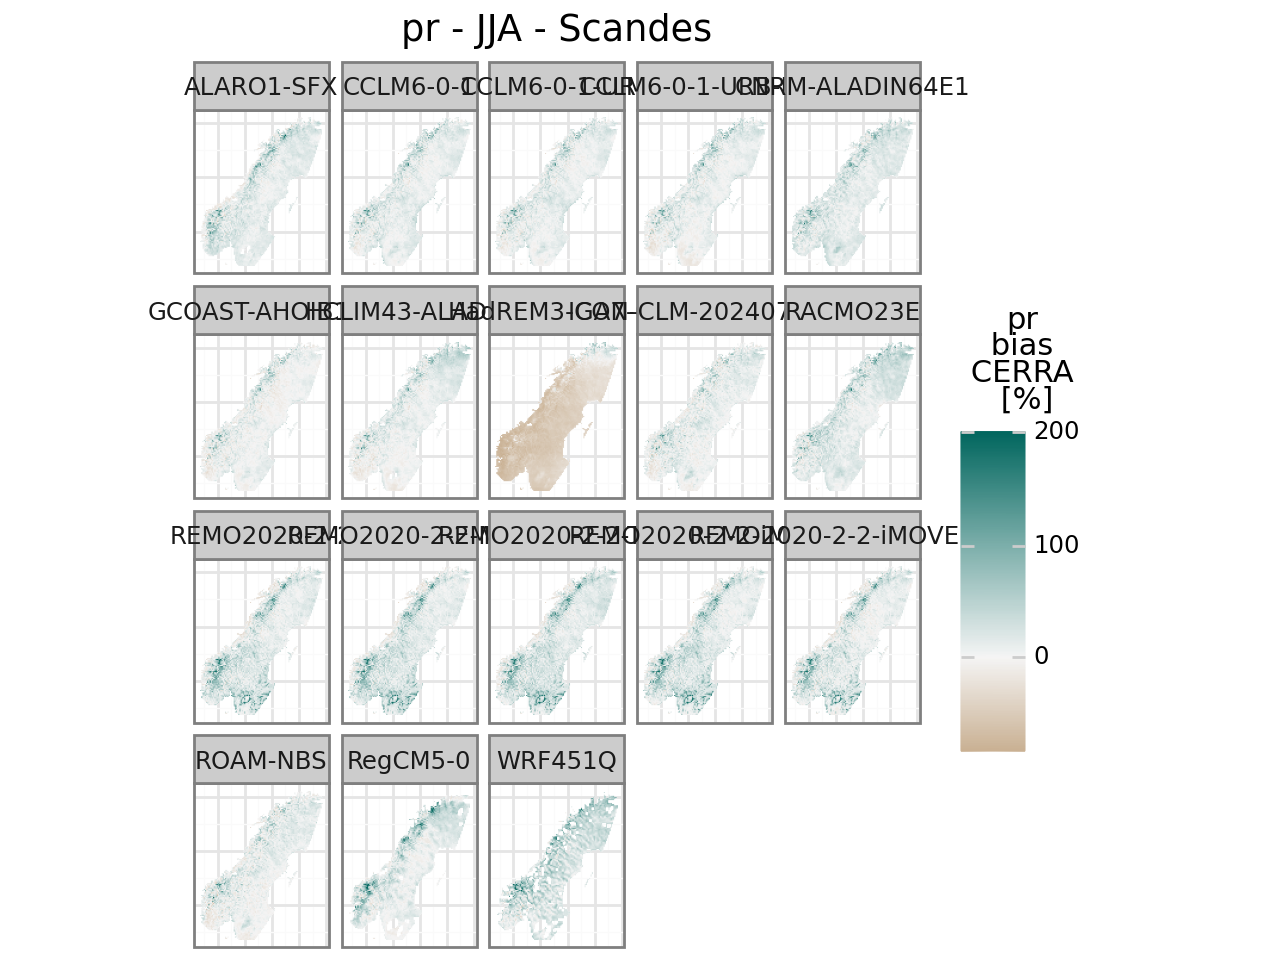

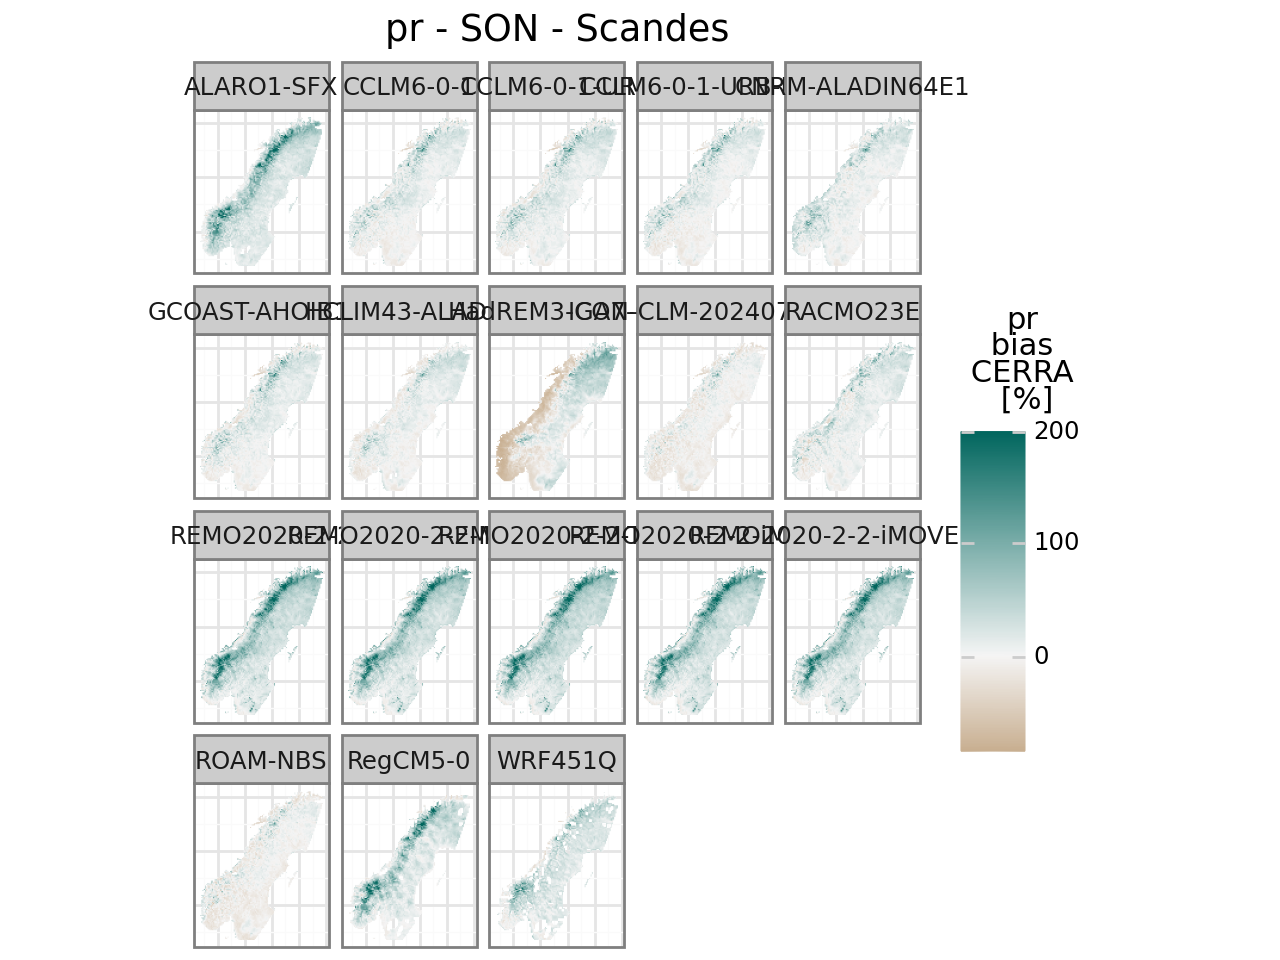

In [10]:
if variable == "pr":
    col_high = "#01665e"
    col_low = "#8c510a"
else:
    col_low = "#4575b4"
    col_high = "#d73027"

if ref_data == "eobs":
    lbl_ref = "E-OBS"
elif ref_data == "cerra":
    lbl_ref = "CERRA"



for i, region in enumerate(regions):
    for season in ["DJF", "MAM", "JJA", "SON"]:
        
        df_plot = df_regions[(df_regions["region"]==i) & (df_regions["season"]==season)]

        col_limits = [df_plot[variable].min(), df_plot[variable].max()]
        if col_limits[1] > 200:
            col_limits[1] = 200.0
        
        gg = (
            ggplot(df_plot, aes("rlon","rlat",fill=variable))
            + geom_raster()
            # + facet_grid("season", "dset_id")
            + facet_wrap("dset_id")
            + coord_equal()
            + theme_bw()
            + theme(axis_title=element_blank(), 
                    axis_ticks=element_blank(), 
                    axis_text=element_blank())
            + ggtitle(f"{variable} - {season} - {regions[i].name}")
        )
        if variable == "pr":
            gg = gg + (
                scale_fill_gradient2(name=variable + "\n bias \n " + lbl_ref + " \n [%]", 
                                     mid="#f5f5f5", high=col_high, low=col_low,
                                     limits=col_limits, oob=mizani.bounds.squish)
            )
        else:
            gg = gg + (
                scale_fill_gradient2(name=variable + "\n bias \n " + lbl_ref + " \n [°C]", 
                                     mid="#f5f5f5", high=col_high, low=col_low)
            )
        gg.show()
        filepath_save = f"{path_fig}/{variable}_{season}_{region.name}.png"
        gg.save(filepath_save, width=12, height=8, dpi=300, verbose=False)